# Project 2: Predicting Student Dropouts

### What Non-GPA factors cause students to dropout? 

In [268]:
#import needed libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn import tree 
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [269]:
df = pd.read_csv("student_dropout_dataset_v3.csv")
df.set_index('Student_ID', inplace=True)
origin = df
df.head()

,Age,Gender,Family_Income,Internet_Access,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Part_Time_Job,Scholarship,Stress_Index,GPA,Semester_GPA,CGPA,Semester,Department,Parental_Education,Dropout
Student_ID,,,,,,,,,,,,,,,,,,
1,22.1,Male,25000.0,Yes,3.36,86.1,2,20.4,Yes,No,5.5,0.96,0.90,0.90,Year 1,Arts,High School,0
2,20.7,Male,25000.0,Yes,4.30,68.0,2,44.0,No,No,6.8,1.28,1.20,1.19,Year 3,Engineering,Bachelor,1
3,22.4,Male,40183.0,Yes,4.40,70.9,0,48.9,Yes,No,5.5,1.68,1.32,1.32,Year 1,Arts,Master,0
4,24.4,Male,NaN,Yes,NaN,82.2,2,38.6,No,No,NaN,1.78,1.77,1.77,Year 1,CS,High School,1
5,20.5,Female,25319.0,Yes,4.19,75.7,1,23.0,No,No,7.0,1.48,0.91,0.87,Year 4,Business,Bachelor,0


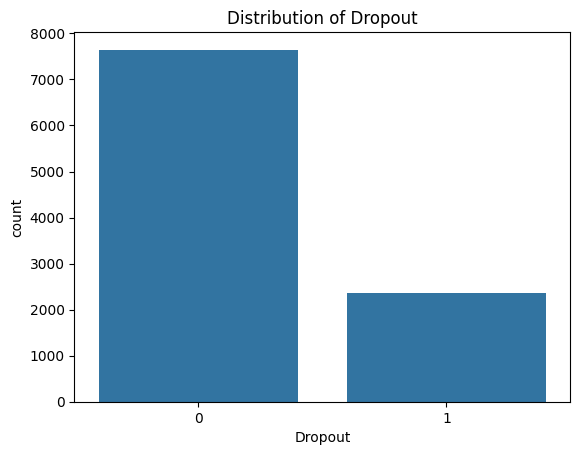

In [270]:
sns.countplot(x="Dropout", data=df)
plt.title("Distribution of Dropout")
plt.show()
#Close to 2,500 students dropped out, while around 7,500 students did not drop out. 
#This indicates that the majority of students in the dataset did not drop out, but there is still a significant portion that did.

## Data Processing 

In [271]:
for col in df.columns:
    print(f"{col}:\n {df[col].value_counts()}\n")

#All columns have atleast 2 unique values, so no columns can be dropped based on having only one unique value.

Age:
 Age
17.0    371
20.9    208
20.5    197
21.7    191
21.4    187
       ... 
28.0      1
28.1      1
29.6      1
28.8      1
28.4      1
Name: count, Length: 115, dtype: int64

Gender:
 Gender
Female    5011
Male      4989
Name: count, dtype: int64

Family_Income:
 Family_Income
25000.0    3668
37713.0       4
52974.0       3
53147.0       3
56345.0       3
           ... 
49322.0       1
42286.0       1
61103.0       1
40302.0       1
56894.0       1
Name: count, Length: 5438, dtype: int64

Internet_Access:
 Internet_Access
Yes    8769
No     1231
Name: count, dtype: int64

Study_Hours_per_Day:
 Study_Hours_per_Day
3.70    43
3.52    40
3.81    39
3.79    39
3.26    38
        ..
8.30     1
7.75     1
0.93     1
7.04     1
8.28     1
Name: count, Length: 702, dtype: int64

Attendance_Rate:
 Attendance_Rate
100.0    122
85.6      61
79.7      61
82.6      60
80.4      59
        ... 
60.1       1
61.7       1
62.4       1
57.3       1
52.9       1
Name: count, Length: 444, dtype: 

In [272]:
df.isna().sum()
#Missing values in Family_income, Parent_Education, Stress_Index, and Study_Hours

Age                        0
Gender                     0
Family_Income            500
Internet_Access            0
Study_Hours_per_Day      500
Attendance_Rate            0
Assignment_Delay_Days      0
Travel_Time_Minutes        0
Part_Time_Job              0
Scholarship                0
Stress_Index             500
GPA                        0
Semester_GPA               0
CGPA                       0
Semester                   0
Department                 0
Parental_Education       511
Dropout                    0
dtype: int64

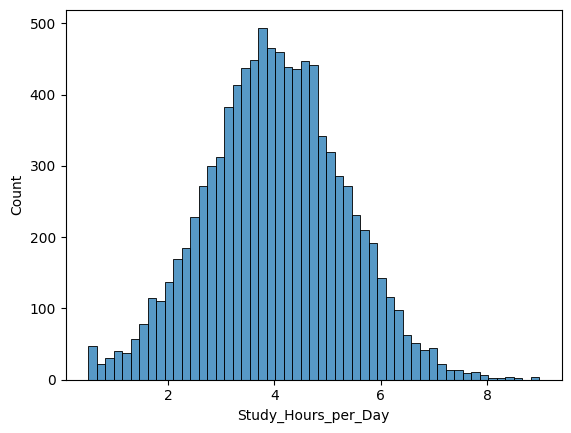

In [273]:
sns.histplot(data=df,x='Study_Hours_per_Day')
df['Study_Hours_per_Day'].fillna(df['Study_Hours_per_Day'].mean(),inplace=True)
#Normal Distribution so we can fill the missing values with the mean.


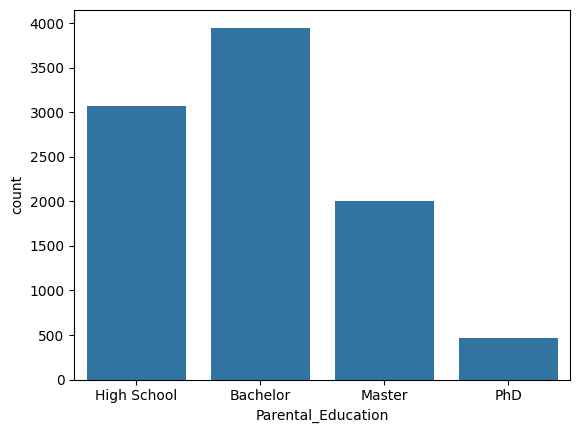

In [274]:
sns.countplot(data=df,x='Parental_Education')
#Since there is no valid way to fill in this data using central numbers we will drop all lines that are missing a parental education.
df = df.dropna()

C:\Users\Administrator\AppData\Local\Temp\ipykernel_10904\3143020991.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Stress_Index'].fillna(df['Stress_Index'].mean(),inplace=True)


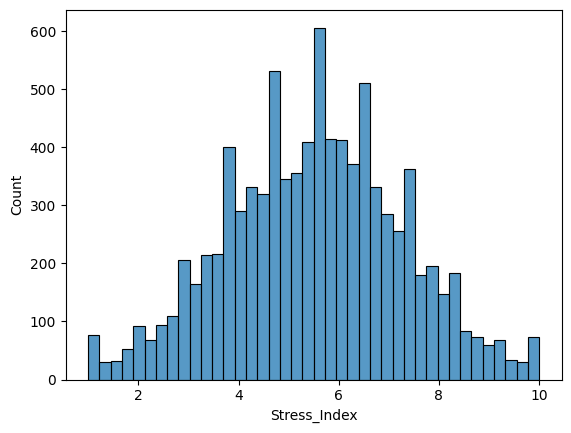

In [275]:
sns.histplot(data=df,x='Stress_Index')
df['Stress_Index'].fillna(df['Stress_Index'].mean(),inplace=True)
#Normal Distribution so we can use the mean in place of NaN values.

C:\Users\Administrator\AppData\Local\Temp\ipykernel_10904\3875469221.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Family_Income'].fillna(df['Family_Income'].median(), inplace=True)
C:\Users\Administrator\AppData\Local\Temp\ipykernel_10904\3875469221.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Family_Income'] = df['Family_Income']/10


<Axes: xlabel='Family_Income', ylabel='Count'>

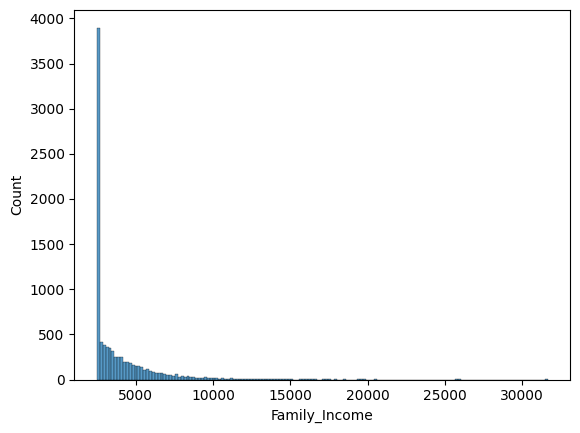

In [276]:
df['Family_Income'].fillna(df['Family_Income'].median(), inplace=True)
df['Family_Income'] = df['Family_Income']/10
sns.histplot(data=df,x='Family_Income')
#Family Income is a skewed distribution, so the median is a better measure of central tendency than the mean. 
#Family Income was also falsely reported and should be divided by 10 because it is monthly income and each value had a trailing zero.

### One Hot Encoding

In [277]:
df = pd.get_dummies(df,columns=['Gender','Internet_Access','Part_Time_Job','Scholarship','Semester','Parental_Education','Department'])
#Drop Extra Unneeded Columns
df.drop(columns=["Gender_Male","Internet_Access_No","Part_Time_Job_No","Scholarship_No"])
#This is better than using drop first as columns like Parental_Education_Bachelor would be removed from the dataset.

,Age,Family_Income,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Stress_Index,GPA,Semester_GPA,CGPA,...,Semester_Year 4,Parental_Education_Bachelor,Parental_Education_High School,Parental_Education_Master,Parental_Education_PhD,Department_Arts,Department_Business,Department_CS,Department_Engineering,Department_Science
Student_ID,,,,,,,,,,,,,,,,,,,,,
1,22.1,2500.0,3.36,86.1,2,20.4,5.5,0.96,0.90,0.90,...,False,False,True,False,False,True,False,False,False,False
2,20.7,2500.0,4.30,68.0,2,44.0,6.8,1.28,1.20,1.19,...,False,True,False,False,False,False,False,False,True,False
3,22.4,4018.3,4.40,70.9,0,48.9,5.5,1.68,1.32,1.32,...,False,False,False,True,False,True,False,False,False,False
5,20.5,2531.9,4.19,75.7,1,23.0,7.0,1.48,0.91,0.87,...,True,True,False,False,False,False,True,False,False,False
7,24.5,2500.0,3.00,78.2,1,37.4,7.3,0.64,0.33,0.44,...,True,True,False,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9996,23.9,4228.6,4.62,92.0,0,10.0,5.5,1.60,0.99,0.97,...,False,True,False,False,False,True,False,False,False,False
9997,17.0,6110.3,2.87,75.2,3,32.4,6.7,3.09,3.09,3.09,...,False,False,False,True,False,False,True,False,False,False
9998,19.4,2500.0,4.73,74.9,4,25.4,3.5,3.45,3.37,3.43,...,True,True,False,False,False,False,True,False,False,False


In [278]:
df.drop(columns=["GPA","Semester_GPA","CGPA"], inplace=True)

<Axes: xlabel='Family_Income', ylabel='Count'>

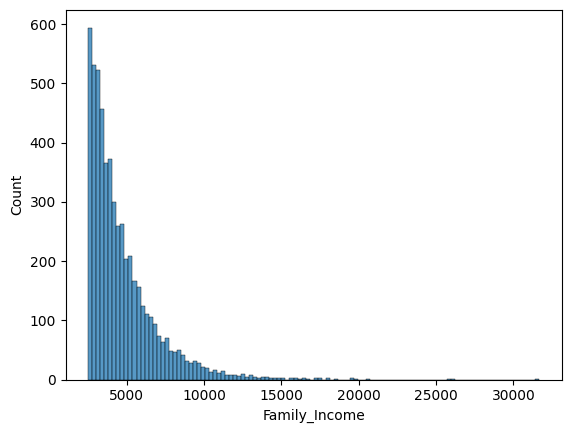

In [279]:
#This dataset is synthetic and for some reason has a lot of students with a family income of 2500, which is likely an error.
#The only way to fix this is to drop all students with a family income of 2500, which is 3,668 students.
#We will save this dataset so we can use it for a later model.
df_2500 = df
df = df[df['Family_Income'] != 2500]
sns.histplot(data=df,x='Family_Income')

In [280]:
df.isna().sum()
#Now that all missing values are taken care of and GPA is removed we can start working on the model.

Age                               0
Family_Income                     0
Study_Hours_per_Day               0
Attendance_Rate                   0
Assignment_Delay_Days             0
Travel_Time_Minutes               0
Stress_Index                      0
Dropout                           0
Gender_Female                     0
Gender_Male                       0
Internet_Access_No                0
Internet_Access_Yes               0
Part_Time_Job_No                  0
Part_Time_Job_Yes                 0
Scholarship_No                    0
Scholarship_Yes                   0
Semester_Year 1                   0
Semester_Year 2                   0
Semester_Year 3                   0
Semester_Year 4                   0
Parental_Education_Bachelor       0
Parental_Education_High School    0
Parental_Education_Master         0
Parental_Education_PhD            0
Department_Arts                   0
Department_Business               0
Department_CS                     0
Department_Engineering      

## Modeling 

In [281]:
X = df.drop(columns="Dropout")
y = df["Dropout"]

In [282]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=.2)
#Split the data set to create a test and training data set to test the accuracy of the model afterwards

In [283]:
clf = tree.DecisionTreeClassifier()
#Intiate Tree Classifier

In [284]:
print("X_train", X_train.shape)
print("X_test", X_test.shape)
print("y_train", y_train.shape)
print("y_test", y_test.shape)

X_train (4429, 28)
X_test (1108, 28)
y_train (4429,)
y_test (1108,)


In [285]:
clf = clf.fit(X_train,y_train)
#fit the model to the training data

In [286]:
clf.score(X_test,y_test)
#test accuracy of the model.

0.6750902527075813

### White box model

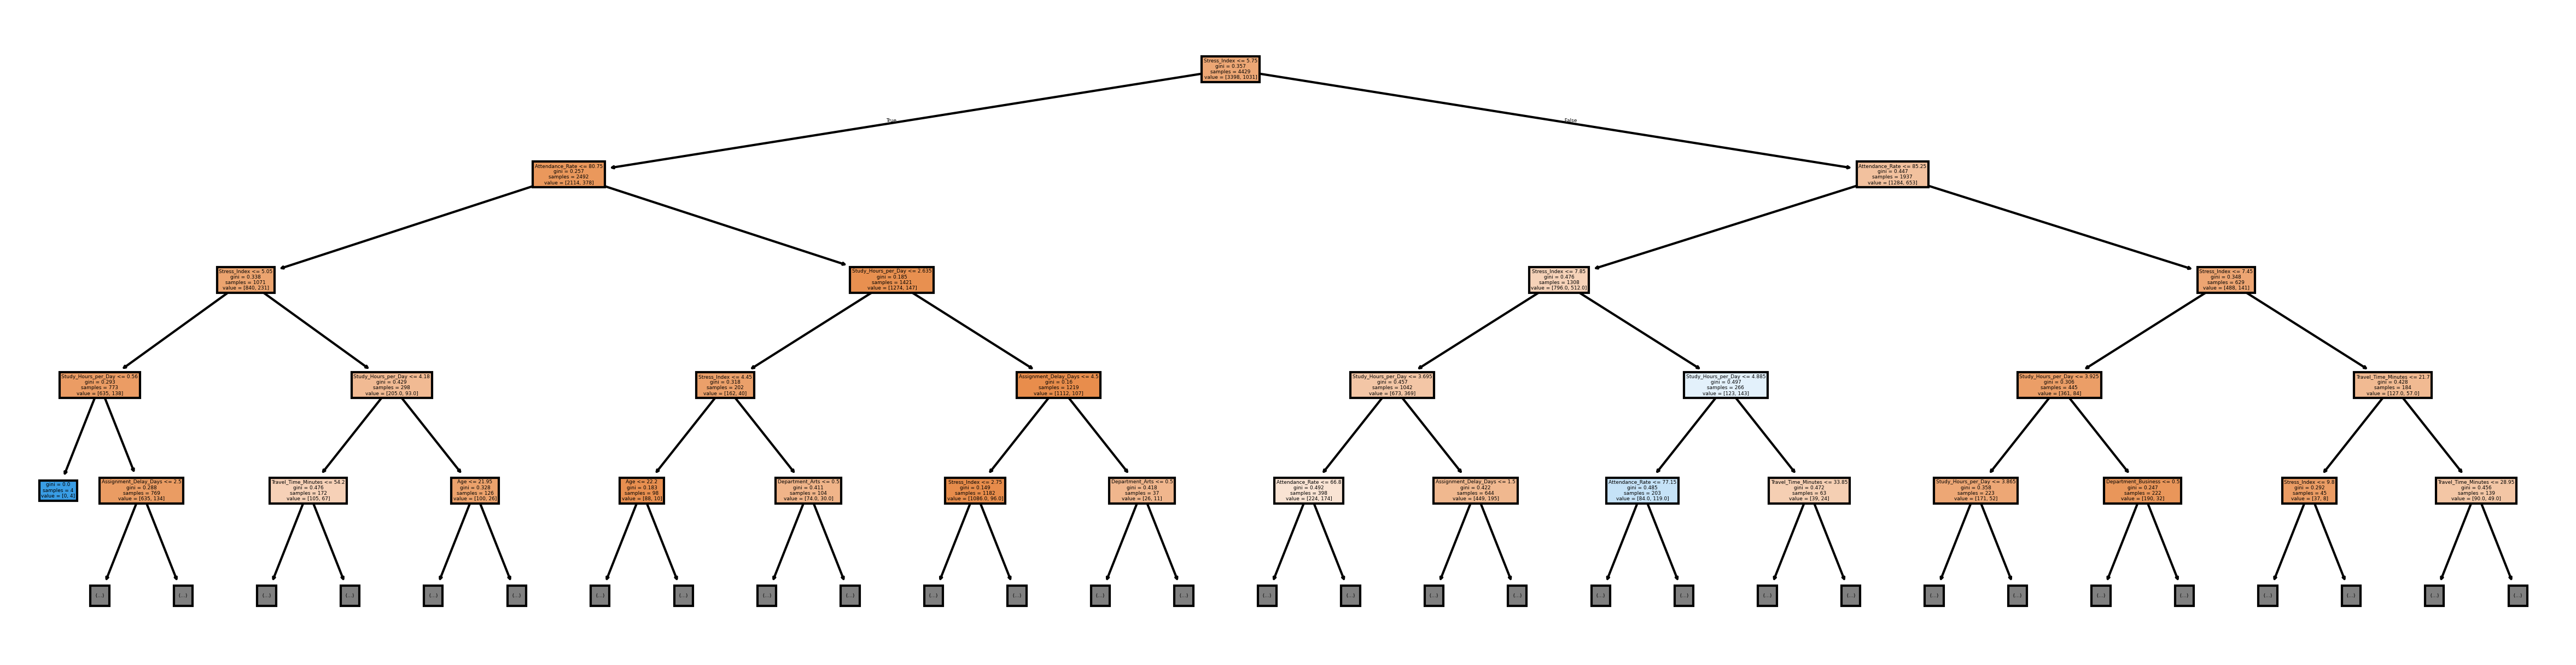

In [287]:
fig, axes = plt.subplots(nrows = 1,ncols = 1, figsize = (20,5), dpi=300)
tree.plot_tree(clf, max_depth = 4, feature_names = X.columns, filled=True)
plt.show()

C:\Users\Administrator\AppData\Local\Temp\ipykernel_10904\89601569.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  chart.set_xticklabels(chart.get_xticklabels(), rotation=45, horizontalalignment='right')


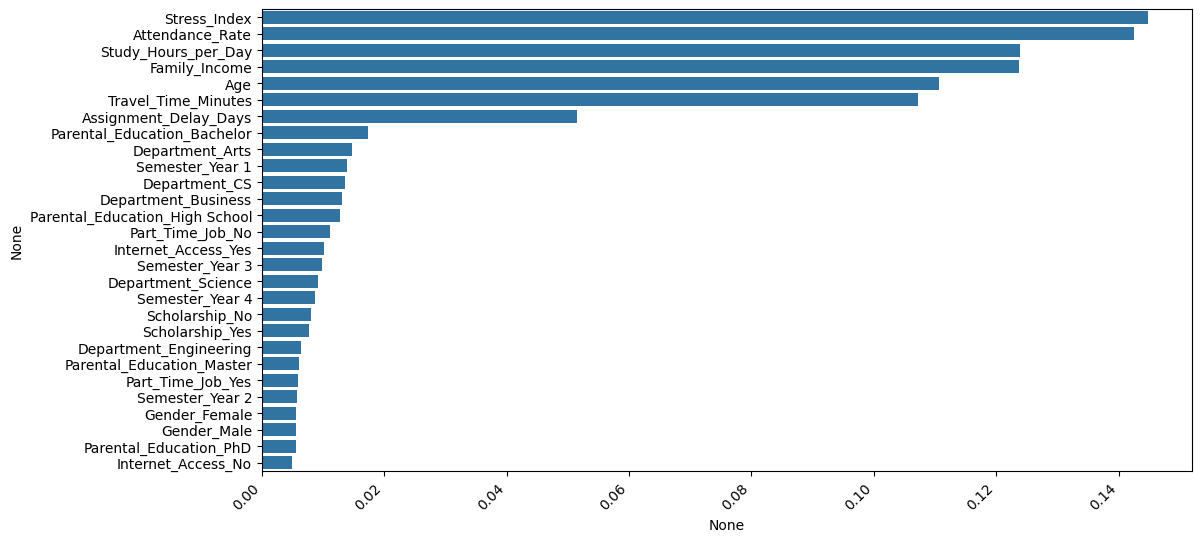

In [288]:
fi = clf.feature_importances_ #feature importance array
fi = pd.Series(data = fi, index = X.columns) #convert to Pandas series for plotting
fi.sort_values(ascending=False, inplace=True) #sort descending
#create bar plot
plt.figure(figsize=(12, 6))
chart = sns.barplot(x=fi, y=fi.index)
chart.set_xticklabels(chart.get_xticklabels(), rotation=45, horizontalalignment='right')
plt.show()

#### Model 2 (No Stress Index)

In [289]:
df2 = df
df2.drop(columns=["Stress_Index"], inplace=True)

C:\Users\Administrator\AppData\Local\Temp\ipykernel_10904\421739578.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2.drop(columns=["Stress_Index"], inplace=True)


In [290]:
X2 = df2.drop(columns="Dropout")
y2 = df2["Dropout"]

In [291]:
X2_train, X2_test, y2_train, y2_test = train_test_split(X2,y2, test_size=.2)

In [292]:
print("X2_train", X2_train.shape)
print("X2_test", X2_test.shape)
print("y2_train", y2_train.shape)
print("y2_test", y2_test.shape)

X2_train (4429, 27)
X2_test (1108, 27)
y2_train (4429,)
y2_test (1108,)


In [293]:
clf2 = tree.DecisionTreeClassifier()
clf2 = clf2.fit(X2_train,y2_train)

In [294]:
clf2.score(X2_test,y2_test)

0.6290613718411552

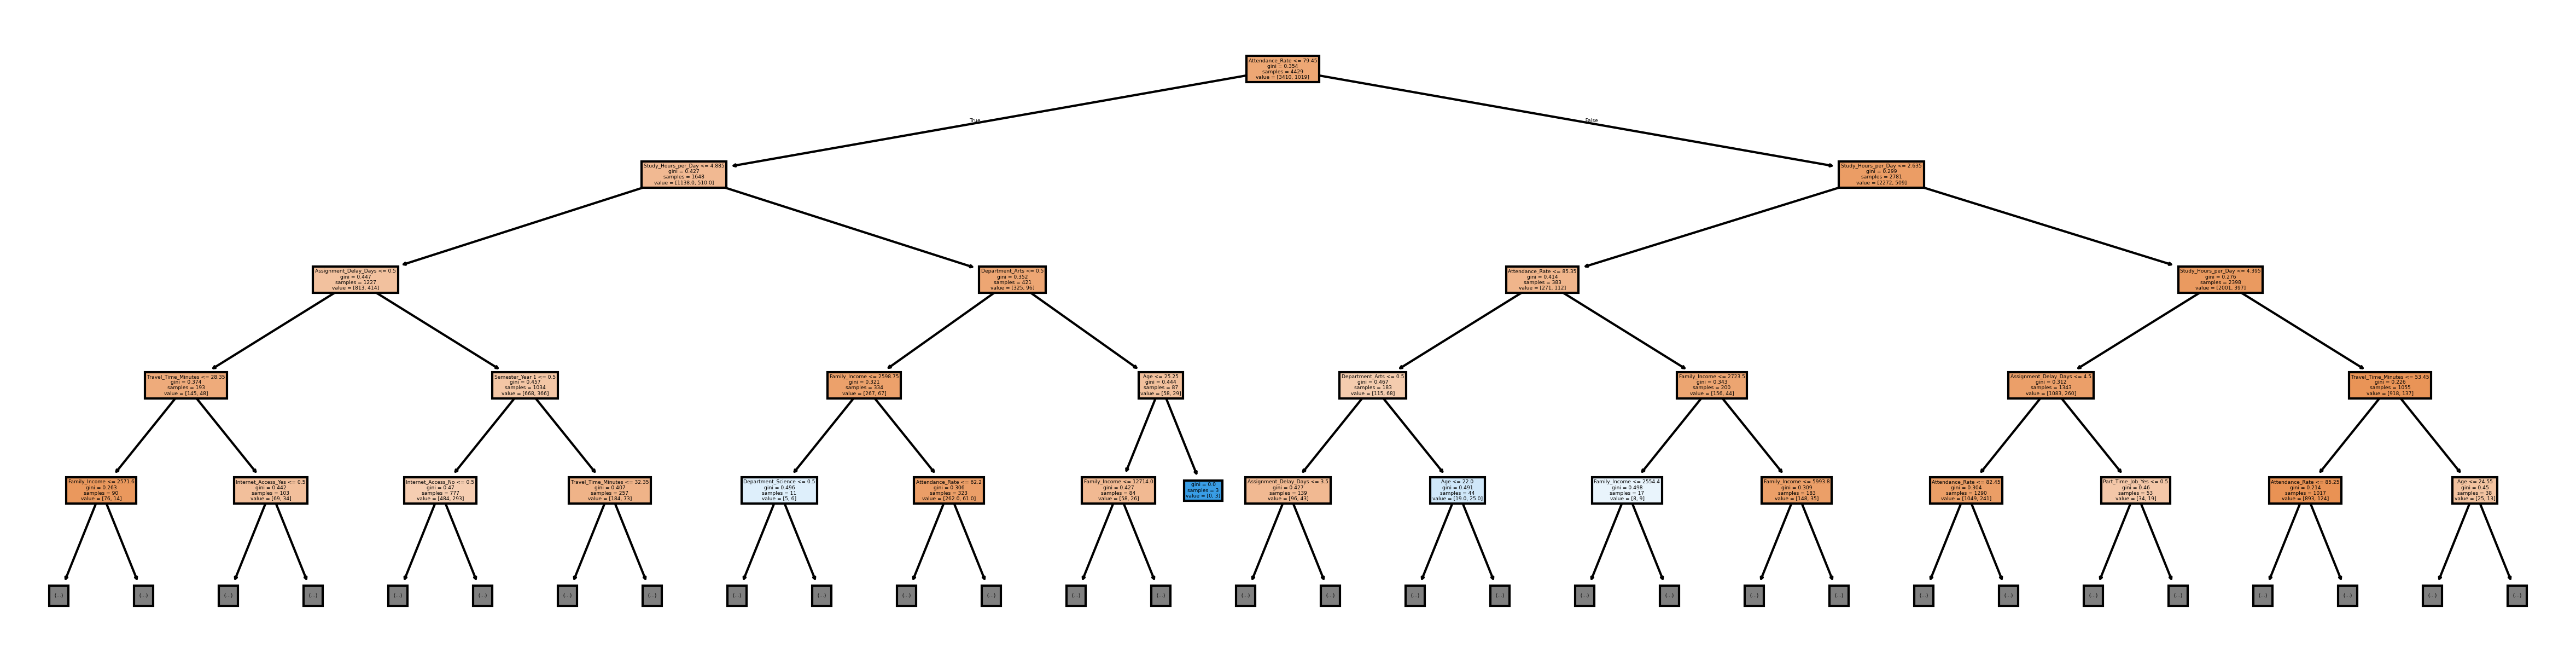

In [295]:
fig, axes = plt.subplots(nrows = 1,ncols = 1, figsize = (20,5), dpi=300)
tree.plot_tree(clf2, max_depth = 4, feature_names = X2.columns, filled=True)
plt.show()

C:\Users\Administrator\AppData\Local\Temp\ipykernel_10904\2215120876.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  chart.set_xticklabels(chart.get_xticklabels(), rotation=45, horizontalalignment='right')


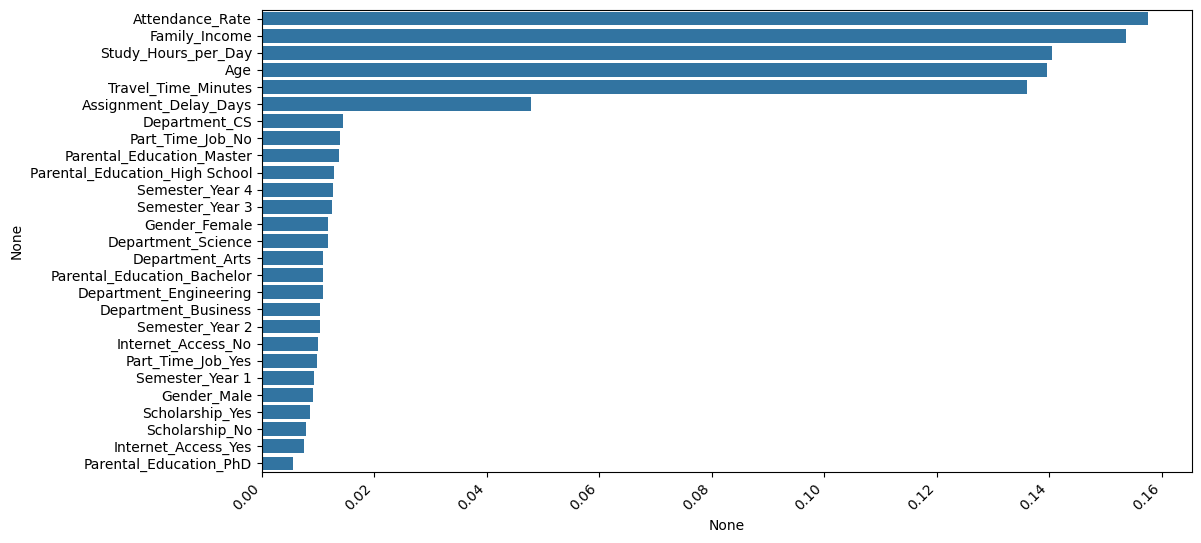

In [296]:
fi2 = clf2.feature_importances_ #feature importance array
fi2 = pd.Series(data = fi2, index = X2.columns) #convert to Pandas series for plotting
fi2.sort_values(ascending=False, inplace=True) #sort descending
#create bar plot
plt.figure(figsize=(12, 6))
chart = sns.barplot(x=fi2, y=fi2.index)
chart.set_xticklabels(chart.get_xticklabels(), rotation=45, horizontalalignment='right')
plt.show()

6 Major factors determine if a student will drop out. Attendance, Age, Stress, Travel Time, Family Income and Study Hours.

#### Model 3 (Without removing the Family Income = 2500)

In [297]:
#Set df3 to the unedited dataset so that we can use it for the next model.
#This is a good model to create to see if the students with a family income of 2500 are skewing the results of the model.
# If the accuracy is much higher then we know that the students with a family income of 2500 are skewing the results and should be removed from the dataset.
df3 = df_2500

In [298]:
X3 = df3.drop(columns="Dropout")
y3 = df3["Dropout"]

In [299]:
X3_train, X3_test, y3_train, y3_test = train_test_split(X3,y3, test_size=.2)

In [300]:
print("X_train", X3_train.shape)
print("X_test", X3_test.shape)
print("y_train", y3_train.shape)
print("y_test", y3_test.shape)

X_train (7216, 28)
X_test (1804, 28)
y_train (7216,)
y_test (1804,)


In [301]:
clf3 = tree.DecisionTreeClassifier()
clf3 = clf3.fit(X3_train,y3_train)
clf3.score(X3_test,y3_test)

0.6906873614190687

C:\Users\Administrator\AppData\Local\Temp\ipykernel_10904\2246691144.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  chart.set_xticklabels(chart.get_xticklabels(), rotation=45, horizontalalignment='right')


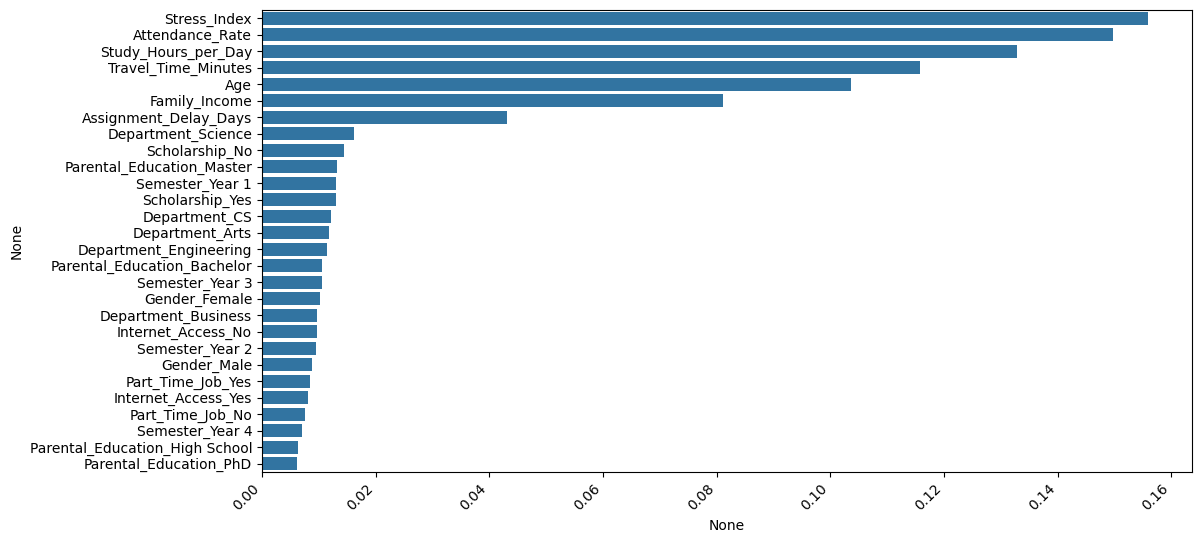

In [308]:
fi3 = clf3.feature_importances_ #feature importance array
fi3 = pd.Series(data = fi3, index = X3.columns) #convert to Pandas series for plotting
fi3.sort_values(ascending=False, inplace=True) #sort descending
#create bar plot
plt.figure(figsize=(12, 6))
chart = sns.barplot(x=fi3, y=fi3.index)
chart.set_xticklabels(chart.get_xticklabels(), rotation=45, horizontalalignment='right')
plt.show()

### Confusion Matrixes

In [302]:
from sklearn.metrics import confusion_matrix

We will make a confusion matrix to test for potential false positives and negatives and compare it to the other models.

In [303]:
y3_pred = clf3.predict(X3_test)
y2_pred = clf2.predict(X2_test)
y_pred = clf.predict(X_test)

In [304]:
cm = confusion_matrix(y_test, y_pred)
cm2 = confusion_matrix(y2_test, y2_pred)
cm3 = confusion_matrix(y3_test, y3_pred)
print(f"Model 1: {cm}")
print(f"Model 2: {cm2}")
print(f"Model 3: {cm3}")

Model 1: [[657 205]
 [155  91]]
Model 2: [[629 221]
 [190  68]]
Model 3: [[1096  302]
 [ 256  150]]


In [306]:
print(f"Model 1 proportion of false predictions: {(cm[1][0] + cm[0][1])/cm.sum()}") #False Negatives and False Positives
print(f"Model 2 proportion of false predictions: {(cm2[1][0] + cm2[0][1])/cm2.sum()}") #False Negatives and False Positives
print(f"Model 3 proportion of false predictions: {(cm3[1][0] + cm3[0][1])/cm3.sum()}") #False Negatives and False Positives

Model 1 proportion of false predictions: 0.3249097472924188
Model 2 proportion of false predictions: 0.37093862815884476
Model 3 proportion of false predictions: 0.3093126385809313


In [307]:
print(f"Model 1 proportion of true predictions: {cm[1][1]/cm.sum()}") #True Positives
print(f"Model 2 proportion of true predictions: {cm2[1][1]/cm2.sum()}") #True Positives
print(f"Model 3 proportion of true predictions: {cm3[1][1]/cm3.sum()}") #True Positives

Model 1 proportion of true predictions: 0.08212996389891697
Model 2 proportion of true predictions: 0.061371841155234655
Model 3 proportion of true predictions: 0.08314855875831485


Surprisingly Model three is the most accurate of the three models prediciting the least false positives and false negatives while still predicting a solid amount of true positives. This would mean removing the 3,300 students did affect the accuracy of the dataset and it is still able to predict the same amount of true positives while predicting less false predictions. It also shows that removing stress index makes it harder for the model predict the correct result.

## Final Conclusion

In conclusion there are 6 major non GPA factors that affects if a student will dropout. Those 6 being Age, Attendance, Study hours per day, Travel Time, and Family Income. All three models used these factors the most when prediciting if a student would drop out or not. I was surprised to find out that the most accurate model was actually the model that kept the 3,000 students that all had 2500 montly family income. This was surprising to me as I thought the large input of the same income would create a bias. If I were to do this project again I would pick a different dataset that wasn't synthetically created as there was a lot of data processing I had to do and make decisions about what the creator meant. I proved that my decision to remove the 3000 students was not the correct decision and hopefully wouldn't have to deal with that with a dataset that contained the data from actual students.